In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re
pd.options.display.float_format = '{:.2f}'.format
pd.set_option('future.no_silent_downcasting', True)

# OVERVIEW 
The choosen dataset contains comprehensive details about car prices, encompassing factors like manufacturer, model, mileage, transmission type, and engine specifications. The goal is to develop a regression model to accurately forecast car prices. Beginning with data preparation, steps include loading the dataset into a pandas DataFrame, handling missing values, and encoding categorical variables like owner and labelling other variables like company, model , seller , transmission, etc. Following this, null and duplicated values are removed while outliers being removed for km_driven as a test parameter. Different visual graphs are shown to show relations and patterns for the data. A test train model is built using random forest,gradient boost regressor while checking through cross-validation and analysis of overfitting or underfitting of the model

In [2]:
df_main = pd.read_csv('/kaggle/input/cardekho.csv.csv')
df_main.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.00
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.00
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.00
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.00
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.00


In [3]:
df_main = df_main.apply(lambda x: x.str.upper() if x.dtype == 'object' else x)
df_main.columns = df_main.columns.str.upper()
df_main[['COMPANY', 'MODEL']] = df_main['NAME'].str.split(r'[-_ ]', n=1, expand=True)
df_main=df_main.drop(columns=['NAME','TORQUE','SEATS'],axis=1)
order=['YEAR','COMPANY','MODEL','FUEL','TRANSMISSION','OWNER','KM_DRIVEN','ENGINE','MILEAGE','MAX_POWER','SELLING_PRICE','SELLER_TYPE']
df_main=df_main[order]
def extract_numerical_value(text):
    numerical_value = re.findall(r'\d+\.?\d*', str(text))
    if numerical_value:
        return float(numerical_value[0])  
    else:
        return None  
df_main['ENGINE'] = df_main['ENGINE'].apply(extract_numerical_value)
df_main['MILEAGE'] = df_main['MILEAGE'].apply(extract_numerical_value)
df_main['MAX_POWER'] = df_main['MAX_POWER'].apply(extract_numerical_value)
df_main=df_main.rename(columns={'MILEAGE':'MILEAGE(KMPL)','ENGINE':'ENGINE(CC)','MAX_POWER':'MAX_POWER(BPH)'})
df_main = df_main[df_main['FUEL'] != 'LPG']
df_main.head()

,YEAR,COMPANY,MODEL,FUEL,TRANSMISSION,OWNER,KM_DRIVEN,ENGINE(CC),MILEAGE(KMPL),MAX_POWER(BPH),SELLING_PRICE,SELLER_TYPE
0,2014,MARUTI,SWIFT DZIRE VDI,DIESEL,MANUAL,FIRST OWNER,145500,1248.00,23.40,74.00,450000,INDIVIDUAL
1,2014,SKODA,RAPID 1.5 TDI AMBITION,DIESEL,MANUAL,SECOND OWNER,120000,1498.00,21.14,103.52,370000,INDIVIDUAL
2,2006,HONDA,CITY 2017-2020 EXI,PETROL,MANUAL,THIRD OWNER,140000,1497.00,17.70,78.00,158000,INDIVIDUAL
3,2010,HYUNDAI,I20 SPORTZ DIESEL,DIESEL,MANUAL,FIRST OWNER,127000,1396.00,23.00,90.00,225000,INDIVIDUAL
4,2007,MARUTI,SWIFT VXI BSIII,PETROL,MANUAL,FIRST OWNER,120000,1298.00,16.10,88.20,130000,INDIVIDUAL


The data frame excel visual is changed here with creating columns for company and model separately and dropping off few columns. Numerical values are extracted for mileage, max power and engine which helps further in model prediciton. Columns are renamed and LPG rows are dropped because of its low percentange and different measurement terms while upper-casing all the data for a better visual


In [4]:
df_main.shape

(8090, 12)

In [5]:
df_main.isna().sum()

YEAR                0
COMPANY             0
MODEL               0
FUEL                0
TRANSMISSION        0
OWNER               0
KM_DRIVEN           0
ENGINE(CC)        218
MILEAGE(KMPL)     218
MAX_POWER(BPH)    213
SELLING_PRICE       0
SELLER_TYPE         0
dtype: int64

In [6]:
df_main.dropna(inplace=True)
df_main.shape

(7871, 12)

Dropping off all the null values and modifying the original data frame

In [7]:
df_main.duplicated().sum()

np.int64(1189)

In [8]:
df_main.drop_duplicates(inplace=True)
df_main.shape

(6682, 12)

Dropping off all the duplicated values and modifying the original data frame

<Axes: xlabel='KM_DRIVEN'>

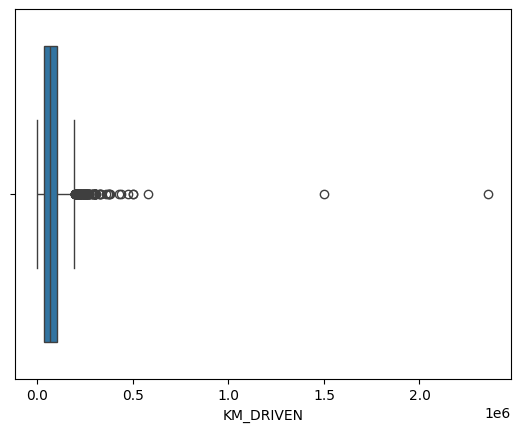

In [9]:
sns.boxplot(x=df_main['KM_DRIVEN'])

box plot of km_driven to check for outliers visually

In [10]:
#removing outliers
def remove_outliers(df_main, columns):
    for column in columns:
        Q1 = df_main[column].quantile(0.25)
        Q3 = df_main[column].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df_main = df_main[(df_main[column] >= lower_bound) & (df_main[column] <= upper_bound)]
    return df_main

columns_to_check = ['KM_DRIVEN'] 
df_main = remove_outliers(df_main, columns_to_check)
df_main.head()

,YEAR,COMPANY,MODEL,FUEL,TRANSMISSION,OWNER,KM_DRIVEN,ENGINE(CC),MILEAGE(KMPL),MAX_POWER(BPH),SELLING_PRICE,SELLER_TYPE
0,2014,MARUTI,SWIFT DZIRE VDI,DIESEL,MANUAL,FIRST OWNER,145500,1248.00,23.40,74.00,450000,INDIVIDUAL
1,2014,SKODA,RAPID 1.5 TDI AMBITION,DIESEL,MANUAL,SECOND OWNER,120000,1498.00,21.14,103.52,370000,INDIVIDUAL
2,2006,HONDA,CITY 2017-2020 EXI,PETROL,MANUAL,THIRD OWNER,140000,1497.00,17.70,78.00,158000,INDIVIDUAL
3,2010,HYUNDAI,I20 SPORTZ DIESEL,DIESEL,MANUAL,FIRST OWNER,127000,1396.00,23.00,90.00,225000,INDIVIDUAL
4,2007,MARUTI,SWIFT VXI BSIII,PETROL,MANUAL,FIRST OWNER,120000,1298.00,16.10,88.20,130000,INDIVIDUAL


**IQR TECHNIQUE**

Outliers, or data points significantly distant from the rest of the dataset, can distort analyses and models. The Interquartile Range (IQR) method provides a robust approach for detecting and removing outliers. Initially, the dataset is sorted, and the first quartile (Q1) and third quartile (Q3) are computed. Subsequently, the Interquartile Range (IQR) is calculated as the difference between Q3 and Q1. Using this IQR, thresholds for outlier detection are established, typically set at Q1 - 1.5 * IQR for the lower bound and Q3 + 1.5 * IQR for the upper bound. Any data points falling beyond these thresholds are considered outliers and can be filtered or removed from the dataset. The IQR technique is advantageous for its robustness against skewed or non-normally distributed data, enhancing the reliability of statistical analyses and predictive models.

<Axes: xlabel='KM_DRIVEN'>

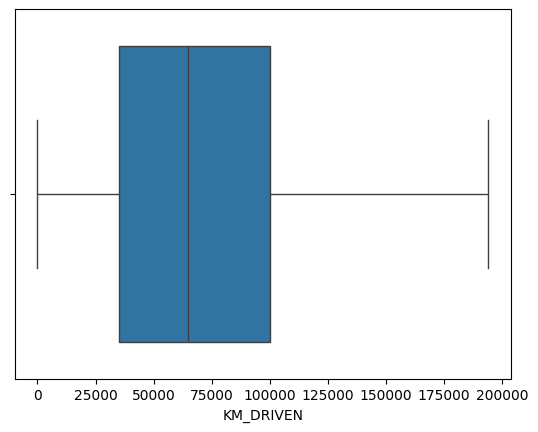

In [11]:
sns.boxplot(x=df_main['KM_DRIVEN'])

outliers are removed for km_driven which can be checked visually

In [12]:
df_main.shape

(6524, 12)

In [13]:
#label encoding the columns
from sklearn.preprocessing import LabelEncoder
df=df_main
df['OWNER_encoded'] =LabelEncoder().fit_transform(df_main['OWNER'])
df['SELLER_encoded'] =LabelEncoder().fit_transform(df_main['SELLER_TYPE'])
df['MODEL_encoded'] =LabelEncoder().fit_transform(df_main['MODEL'])
df['COMPANY_encoded'] =LabelEncoder().fit_transform(df_main['COMPANY'])
df = pd.DataFrame(df)
df=df.drop(columns=['COMPANY','MODEL','SELLER_TYPE','OWNER'],axis=1)
desired_column_order = ['YEAR','COMPANY_encoded', 'MODEL_encoded', 'FUEL','TRANSMISSION','OWNER_encoded','KM_DRIVEN','ENGINE(CC)','MILEAGE(KMPL)','MAX_POWER(BPH)','SELLING_PRICE','SELLER_encoded']
df=df[desired_column_order]
df=df.rename(columns={'COMPANY_encoded':'COMPANY','MODEL_encoded':'MODEL','SELLER_encoded':'SELLER','OWNER_encoded':'OWNER'})
df.head()

,YEAR,COMPANY,MODEL,FUEL,TRANSMISSION,OWNER,KM_DRIVEN,ENGINE(CC),MILEAGE(KMPL),MAX_POWER(BPH),SELLING_PRICE,SELLER
0,2014,18,1514,DIESEL,MANUAL,0,145500,1248.00,23.40,74.00,450000,1
1,2014,25,1283,DIESEL,MANUAL,2,120000,1498.00,21.14,103.52,370000,1
2,2006,9,342,PETROL,MANUAL,4,140000,1497.00,17.70,78.00,158000,1
3,2010,10,876,DIESEL,MANUAL,0,127000,1396.00,23.00,90.00,225000,1
4,2007,18,1551,PETROL,MANUAL,0,120000,1298.00,16.10,88.20,130000,1


label encoding COMPANY, MODEL, SELLER TYPE, OWNER which helps in providing relations and heatmaps

In [14]:
#one-hot labelling fuel
df_encoded = pd.get_dummies(df, columns=['FUEL','TRANSMISSION'])
df_encoded = df_encoded.replace({True: 1, False: 0})
df_encoded.head()

,YEAR,COMPANY,MODEL,OWNER,KM_DRIVEN,ENGINE(CC),MILEAGE(KMPL),MAX_POWER(BPH),SELLING_PRICE,SELLER,FUEL_CNG,FUEL_DIESEL,FUEL_PETROL,TRANSMISSION_AUTOMATIC,TRANSMISSION_MANUAL
0,2014,18,1514,0,145500,1248.00,23.40,74.00,450000,1,0,1,0,0,1
1,2014,25,1283,2,120000,1498.00,21.14,103.52,370000,1,0,1,0,0,1
2,2006,9,342,4,140000,1497.00,17.70,78.00,158000,1,0,0,1,0,1
3,2010,10,876,0,127000,1396.00,23.00,90.00,225000,1,0,1,0,0,1
4,2007,18,1551,0,120000,1298.00,16.10,88.20,130000,1,0,0,1,0,1


one hot encoding TRANSMISSION and FUEL TYPE

# DATA VISUALS

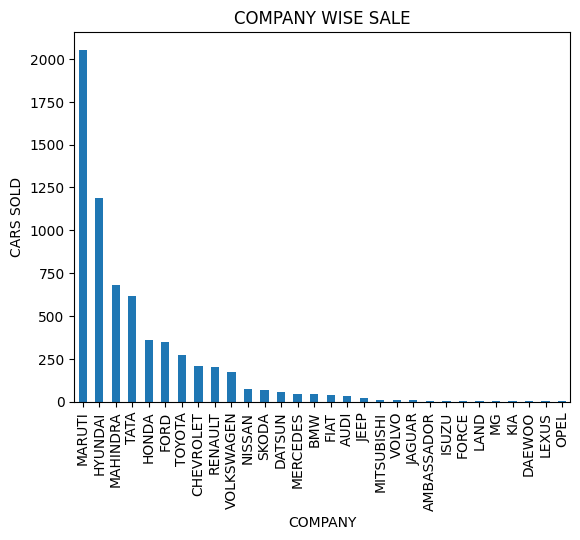

In [15]:
df_main['COMPANY'].value_counts().plot(kind='bar')
plt.title('COMPANY WISE SALE')
plt.xlabel('COMPANY')
plt.ylabel('CARS SOLD')
plt.show()

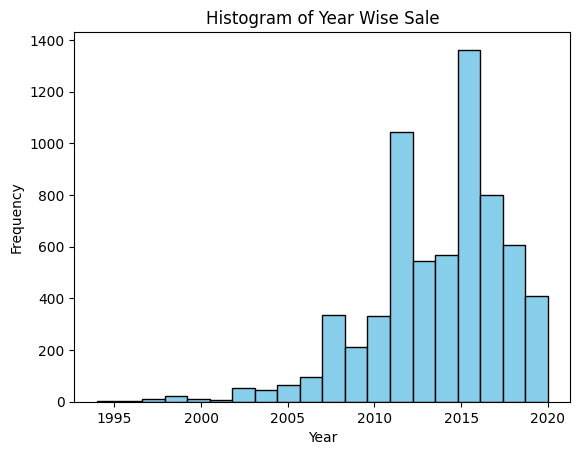

In [16]:
plt.hist(df_main['YEAR'], bins=20, color='skyblue', edgecolor='black')
plt.title('Histogram of Year Wise Sale')
plt.xlabel('Year')
plt.ylabel('Frequency')
plt.show()

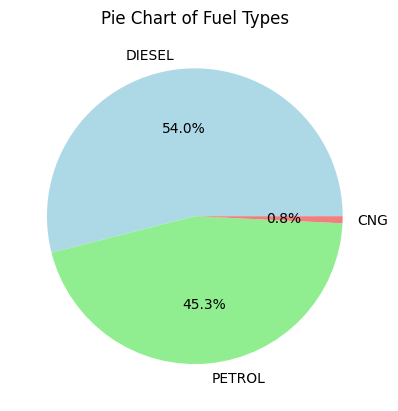

In [17]:
fuel_counts = df_main['FUEL'].value_counts()
colors = ['lightblue', 'lightgreen', 'lightcoral', 'lightskyblue']
plt.pie(fuel_counts, labels=fuel_counts.index, autopct='%1.1f%%', colors=colors)
plt.title('Pie Chart of Fuel Types')
plt.show()

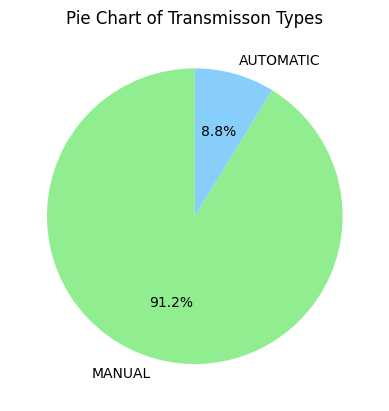

In [18]:
transmission_counts = df_main['TRANSMISSION'].value_counts()
colors = ['lightgreen', 'lightskyblue']
plt.pie(transmission_counts, labels=transmission_counts.index, autopct='%1.1f%%', startangle=90, colors=colors)
plt.title('Pie Chart of Transmisson Types')
plt.show()

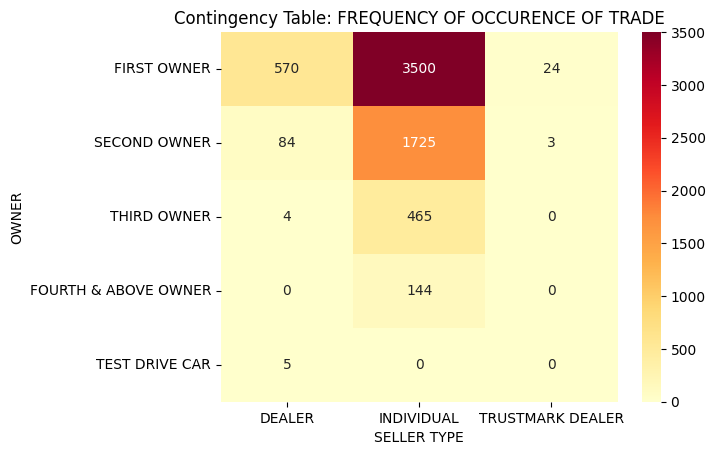

In [19]:
from scipy.stats import chi2_contingency
contingency_table = pd.crosstab(df_main['OWNER'], df_main['SELLER_TYPE'])
owner_order = ['FIRST OWNER', 'SECOND OWNER', 'THIRD OWNER', 'FOURTH & ABOVE OWNER','TEST DRIVE CAR']
contingency_table = contingency_table.reindex(owner_order)
sns.heatmap(contingency_table, annot=True, cmap="YlOrRd", fmt=".0f")
plt.title("Contingency Table: FREQUENCY OF OCCURENCE OF TRADE")
plt.xlabel("SELLER TYPE")
plt.ylabel("OWNER")
plt.show()

The above contingency table shows frequency of occurence of trade between two variables (seller type who sold and owner type who bought)

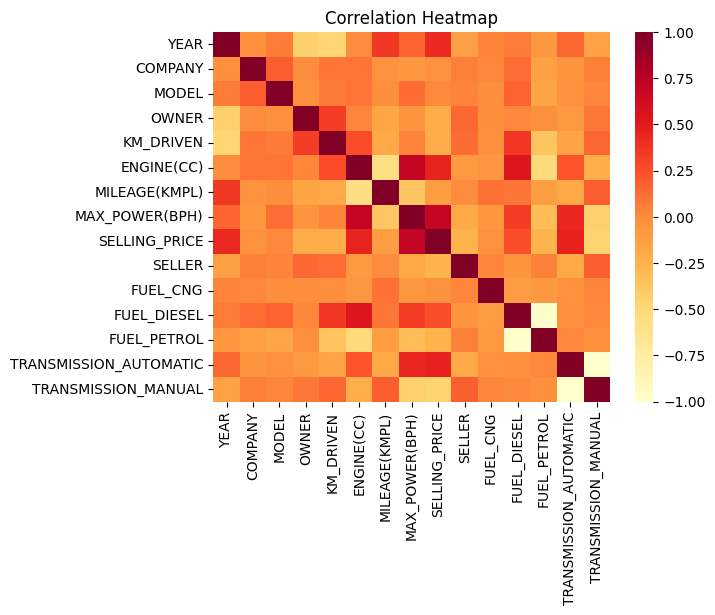

In [20]:
sns.heatmap(df_encoded.corr(),cmap="YlOrRd")
plt.title('Correlation Heatmap')
plt.show()

A correlation heatmap visually represents the correlation coefficients between variables in a dataset using a color gradient. Darker shades indicate stronger correlations, while lighter shades signify weaker ones. It's a powerful tool for identifying patterns and relationships, aiding in feature selection and understanding dataset structure in data analysis and modeling tasks.

In [21]:
df_encoded.head()

,YEAR,COMPANY,MODEL,OWNER,KM_DRIVEN,ENGINE(CC),MILEAGE(KMPL),MAX_POWER(BPH),SELLING_PRICE,SELLER,FUEL_CNG,FUEL_DIESEL,FUEL_PETROL,TRANSMISSION_AUTOMATIC,TRANSMISSION_MANUAL
0,2014,18,1514,0,145500,1248.00,23.40,74.00,450000,1,0,1,0,0,1
1,2014,25,1283,2,120000,1498.00,21.14,103.52,370000,1,0,1,0,0,1
2,2006,9,342,4,140000,1497.00,17.70,78.00,158000,1,0,0,1,0,1
3,2010,10,876,0,127000,1396.00,23.00,90.00,225000,1,0,1,0,0,1
4,2007,18,1551,0,120000,1298.00,16.10,88.20,130000,1,0,0,1,0,1


# MODEL IMPLEMENTATION

# **Random Forest** 
Random Forest is a versatile ensemble learning algorithm that constructs a multitude of decision trees during training. It aggregates predictions from each tree to improve accuracy and reduce overfitting. Each tree is trained on a random subset of the dataset's features, enhancing robustness. Through voting or averaging, Random Forest generates final predictions, making it highly effective for classification and regression tasks across various domains, including finance, healthcare, and marketing.
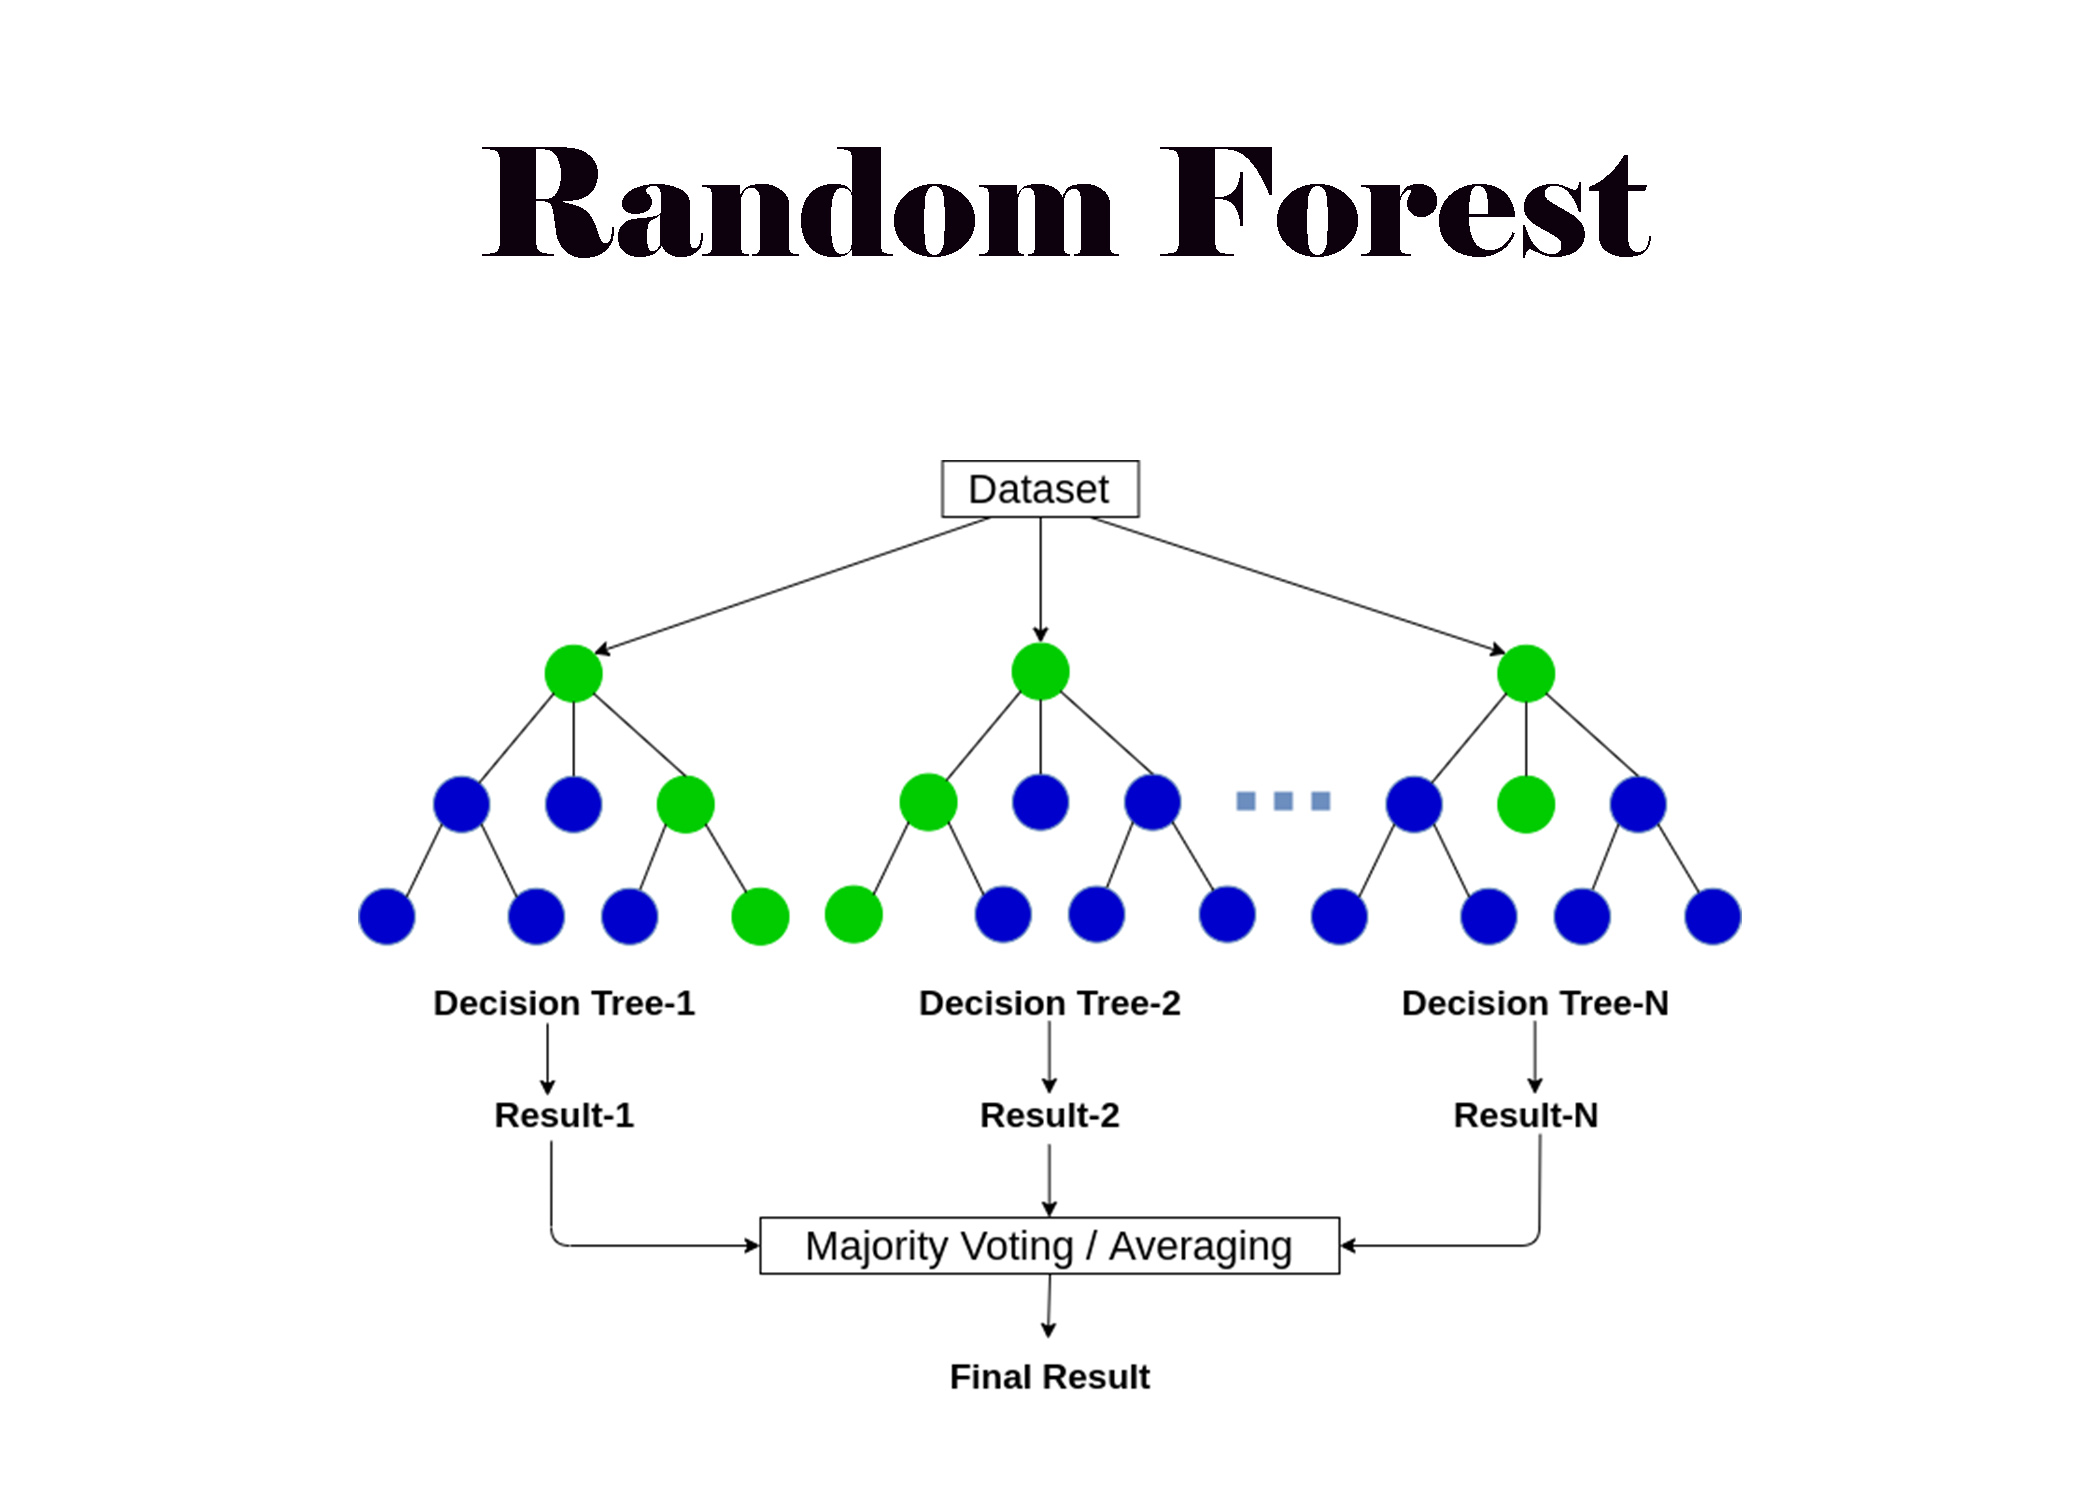

Test R² score: 0.9322423037262496
Test RMSE: 131366.75182254374
Train R² score: 0.9857073741420145
Train RMSE: 63942.39151334002


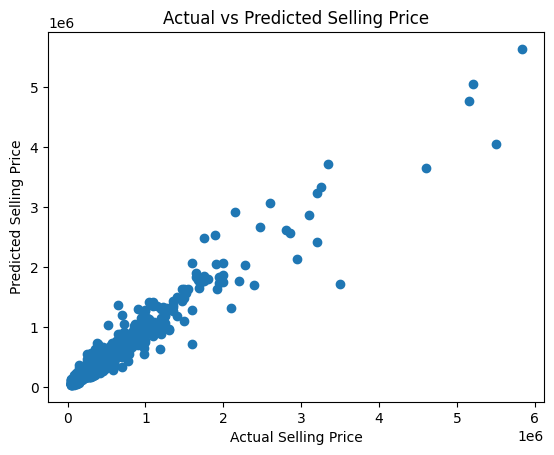

In [22]:
# Random Forest

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, root_mean_squared_error
import matplotlib.pyplot as plt

# Features and target
X = df_encoded.drop(columns=['SELLING_PRICE'])
y = df_encoded['SELLING_PRICE']

# Train-test split
train_X, test_X, train_y, test_y = train_test_split(
    X, y, test_size=0.2, random_state=1
)

# Model
rf_regressor = RandomForestRegressor(
    n_estimators=200,
    random_state=1
)

# Train
rf_regressor.fit(train_X, train_y)

# Test predictions
pred_y = rf_regressor.predict(test_X)

# Test metrics
rmse_test = root_mean_squared_error(test_y, pred_y)
r2_test = r2_score(test_y, pred_y)

# Train predictions
pred_y_train = rf_regressor.predict(train_X)

# Train metrics
rmse_train = root_mean_squared_error(train_y, pred_y_train)
r2_train = r2_score(train_y, pred_y_train)

# Results
print("Test R² score:", r2_test)
print("Test RMSE:", rmse_test)
print("Train R² score:", r2_train)
print("Train RMSE:", rmse_train)

# Actual vs Predicted plot
plt.scatter(test_y, pred_y)
plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Actual vs Predicted Selling Price")
plt.show()

With a high R-squared score of 0.9857 and low RMSE of 63942.39 on the training data, the Random Forest model displays strong fitting capabilities. However, the slightly higher RMSE of 131366.75 on the test data suggests mild overfitting

**Overfitting** is a common challenge in machine learning where a model learns the training data too well, capturing noise and idiosyncrasies instead of the underlying patterns. As a result, the model performs poorly on unseen data, failing to generalize effectively. To mitigate overfitting, techniques like regularization, cross-validation, and feature selection are employed to strike a balance between model complexity and generalization.

**Underfitting** is a phenomenon in machine learning where a model is too simplistic to capture the underlying structure of the data. As a result, it performs poorly not only on the training data but also on unseen data. Underfitting often occurs when the model is too simple relative to the complexity of the data, and addressing it typically involves increasing model complexity, employing more sophisticated algorithms, or gathering additional data.

In [23]:
# cross-validation on random forest regressor
from sklearn.model_selection import cross_val_score,KFold
X = df_encoded.drop(columns=['SELLING_PRICE'])
y = df_encoded['SELLING_PRICE']
rf_regressor = RandomForestRegressor(n_estimators=200, random_state=1)
kfold = KFold(n_splits=5, shuffle=True, random_state=1)
cv_scores = cross_val_score(rf_regressor, X, y, cv=kfold, scoring='r2')
print("Cross-Validation R-squared scores:", cv_scores)
print("Mean R-squared score:", cv_scores.mean())

Cross-Validation R-squared scores: [0.92529679 0.91339021 0.92449948 0.90673223 0.84268741]
Mean R-squared score: 0.9025212244466815


The Random Forest model demonstrates variable performance across different data subsets, with cross-validation R-squared scores ranging from 0.842 to 0.926. Despite minor fluctuations, the model maintains a mean R-squared score of 0.9028, indicating consistent predictive capability and reasonable generalization across the dataset.

# Gradient Boosting Regressor 
Gradient Boosting Regressor is a powerful machine learning algorithm that builds predictive models by combining multiple weak learners sequentially. It works by fitting each new model to the residuals of the previous model, thereby gradually reducing errors and improving predictive accuracy. By iteratively minimizing loss functions, Gradient Boosting Regressor produces highly accurate predictions, making it effective for regression tasks across various domains.

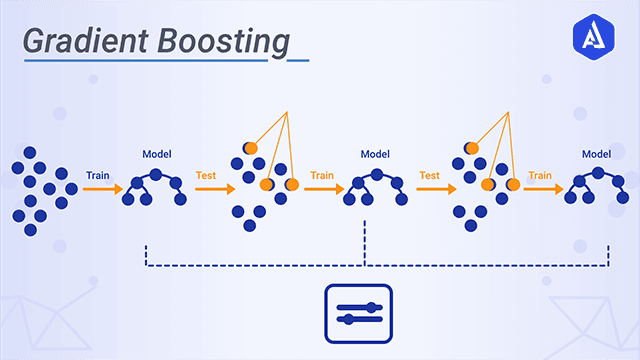

Test R² score: 0.9178648254528723
Test RMSE: 165544.62989017644
Train R² score: 0.9658940336988922
Train RMSE: 95319.07909446243


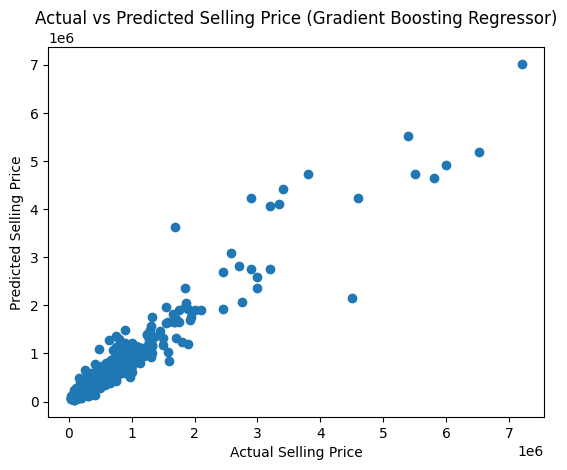

In [24]:
# Gradient Boosting Regressor

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, root_mean_squared_error
import matplotlib.pyplot as plt

# Features and target
X = df_encoded.drop(columns=['SELLING_PRICE'])
y = df_encoded['SELLING_PRICE']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=2
)

# Model
gb_regressor = GradientBoostingRegressor(
    n_estimators=200,
    random_state=2
)

# Train
gb_regressor.fit(X_train, y_train)

# Test predictions
pred_y = gb_regressor.predict(X_test)

# Test metrics
rmse_test = root_mean_squared_error(y_test, pred_y)
r2_test = r2_score(y_test, pred_y)

# Train predictions
pred_y_train = gb_regressor.predict(X_train)

# Train metrics
rmse_train = root_mean_squared_error(y_train, pred_y_train)
r2_train = r2_score(y_train, pred_y_train)

# Results
print("Test R² score:", r2_test)
print("Test RMSE:", rmse_test)
print("Train R² score:", r2_train)
print("Train RMSE:", rmse_train)

# Actual vs Predicted plot
plt.scatter(y_test, pred_y)
plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Actual vs Predicted Selling Price (Gradient Boosting Regressor)")
plt.show()

Gradient Boosting Regressor model appears to be well-fitted to the data. With high R-squared scores of approximately 0.966 on the training set and 0.920 on the test set, along with reasonable RMSE values, the model demonstrates strong explanatory power and generalization capability.

In [25]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.ensemble import GradientBoostingRegressor
import numpy as np

X = df_encoded.drop(columns=['SELLING_PRICE'])
y = df_encoded['SELLING_PRICE']

gb_regressor = GradientBoostingRegressor(n_estimators=200, random_state=2)

kfold = KFold(n_splits=5, shuffle=True, random_state=2)

cv_scores = cross_val_score(gb_regressor, X, y, cv=kfold, scoring='r2')

print("Cross-Validation R-squared scores:", cv_scores)
print("Mean R-squared score:", np.mean(cv_scores))


Cross-Validation R-squared scores: [0.9178755  0.92896173 0.92712822 0.90703716 0.86530223]
Mean R-squared score: 0.9092609676962311


With cv scores ranging from 0.868 to 0.929 and a mean R-squared score of 0.909, the model exhibits consistent performance across different data subsets. This suggests that the model generalizes well and is stable across various portions of the dataset

**NOTES:**
To enhance the performance of the above models, several strategies can be implemented. Using more one hot encoded variables that may better capture underlying relationships in the data. Conducting, hyperparameter tuning using techniques like grid search or randomized search to optimize model settings such as learning rate, tree depth, and the number of estimators.Apply regularization techniques such as shrinkage methods to prevent overfitting and improve model generalization.Explore ensemble learning by combining multiple models trained on different data subsets or using different algorithms to improve predictive performance. Experiment with advanced techniques such as neural networks or other regressor models with better effects and usage of a paramgrid might help. Not implementing other such regressor models because my knowledge is not fully suffice 